Reads the generated backtest outputs from this project directory
(`daily_pnl.csv`, `fills.csv`, `summary.csv`, `fee_adjusted_summary.csv`,
the inventory-skew variant outputs, and the 15:00 sensitivity run). No
results are recomputed or hardcoded here — every number and chart below
comes directly from those files at run time. See `README.md` for full
methodology.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path(".")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# House style, consistent with Task 1's report (EMAAR = navy, EMAARDEV = orange)
COLOR = {"EMAAR": "#1f4e79", "EMAARDEV": "#d97a34"}
GREEN, RED, GRAY = "#2e7d5b", "#b23b3b", "#6b7280"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#333333", "axes.grid": True,
    "grid.color": "#e5e7eb", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110, "axes.axisbelow": True,
})


def short(stock_name: str) -> str:
    """'EMAAR UH Equity' -> 'EMAAR', 'EMAARDEV UH Equity' -> 'EMAARDEV'."""
    return "EMAARDEV" if "EMAARDEV" in stock_name else "EMAAR"


def money(ax=None, axis="y"):
    fmt = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    (ax or plt.gca()).__getattribute__(f"{axis}axis").set_major_formatter(fmt)

In [2]:
daily = pd.read_csv(PROJECT_DIR / "daily_pnl.csv", parse_dates=["date"])
fills = pd.read_csv(PROJECT_DIR / "fills.csv", parse_dates=["timestamp", "scheduled_refill_time"])
summary = pd.read_csv(PROJECT_DIR / "summary.csv")
fees = pd.read_csv(PROJECT_DIR / "fee_adjusted_summary.csv")
daily_skew = pd.read_csv(PROJECT_DIR / "daily_pnl_skewed.csv", parse_dates=["date"])
summary_skew = pd.read_csv(PROJECT_DIR / "summary_skewed.csv")
daily_1500 = pd.read_csv(PROJECT_DIR / "results_1500_sensitivity" / "daily_pnl.csv", parse_dates=["date"])
summary_1500 = pd.read_csv(PROJECT_DIR / "results_1500_sensitivity" / "summary.csv")

stocks = sorted(daily["stock"].unique(), key=short)
for name, df in [("daily_pnl.csv", daily), ("fills.csv", fills), ("summary.csv", summary),
                  ("fee_adjusted_summary.csv", fees), ("daily_pnl_skewed.csv", daily_skew),
                  ("summary_skewed.csv", summary_skew), ("1500-sensitivity daily_pnl.csv", daily_1500)]:
    print(f"{name:32s} {len(df):>7,} rows")
print(f"\nStocks: {stocks}")

daily_pnl.csv                         42 rows
fills.csv                         28,702 rows
summary.csv                            2 rows
fee_adjusted_summary.csv               2 rows
daily_pnl_skewed.csv                  42 rows
summary_skewed.csv                     2 rows
1500-sensitivity daily_pnl.csv        42 rows

Stocks: ['EMAAR UH Equity', 'EMAARDEV UH Equity']


## Executive summary

In [3]:
exec_tbl = summary.merge(fees[["stock", "variable_fee", "flat_fee", "total_fee", "net_pnl"]], on="stock")
exec_tbl["win_rate"] = exec_tbl["profitable_days"] / exec_tbl["number_of_trading_days"]
exec_tbl["short"] = exec_tbl["stock"].map(short)
exec_tbl = exec_tbl.set_index("short")[[
    "total_pnl_aed", "net_pnl", "average_daily_pnl_aed", "win_rate", "max_drawdown_aed",
    "total_gross_traded_value_aed", "total_volume_shares", "total_number_of_fills",
]]
exec_tbl.columns = ["Gross P&L (AED)", "Net P&L after fees (AED)", "Avg daily P&L", "Win rate",
                     "Max drawdown (AED)", "Gross traded value (AED)", "Volume (sh)", "Fills"]

(exec_tbl.style
    .format({"Gross P&L (AED)": "{:,.2f}", "Net P&L after fees (AED)": "{:,.2f}",
             "Avg daily P&L": "{:,.2f}", "Win rate": "{:.0%}", "Max drawdown (AED)": "{:,.2f}",
             "Gross traded value (AED)": "{:,.0f}", "Volume (sh)": "{:,.0f}", "Fills": "{:,d}"})
    .background_gradient(subset=["Gross P&L (AED)", "Net P&L after fees (AED)"], cmap="RdYlGn", axis=None)
    .set_caption("Primary run — 14:45:00 cutoff, locked-market fix applied"))

,Gross P&L (AED),Net P&L after fees (AED),Avg daily P&L,Win rate,Max drawdown (AED),Gross traded value (AED),Volume (sh),Fills
short,,,,,,,,
EMAAR,"17,811.40","-401,271.89",848.16,48%,"-24,620.45","231,153,736","16,625,257","19,179"
EMAARDEV,"-94,003.55","-311,884.51","-4,476.36",62%,"-72,804.90","118,951,907","8,393,511","9,523"


In [4]:
best_stock = exec_tbl["Net P&L after fees (AED)"].idxmax()
worst_dd_stock = exec_tbl["Max drawdown (AED)"].idxmin()
n_days = int(summary["number_of_trading_days"].iloc[0])
print(f"Gross result looks tolerable ("
      + ", ".join(f"{s}: {v:+,.0f} AED" for s, v in exec_tbl['Gross P&L (AED)'].items())
      + f") but neither survives DFM's fee schedule: "
      + ", ".join(f"{s}: {v:+,.0f} AED" for s, v in exec_tbl['Net P&L after fees (AED)'].items())
      + f" net of fees over the {n_days}-day sample. {worst_dd_stock} carries the deeper max "
      f"drawdown at {exec_tbl.loc[worst_dd_stock, 'Max drawdown (AED)']:,.0f} AED.")

Gross result looks tolerable (EMAAR: +17,811 AED, EMAARDEV: -94,004 AED) but neither survives DFM's fee schedule: EMAAR: -401,272 AED, EMAARDEV: -311,885 AED net of fees over the 21-day sample. EMAARDEV carries the deeper max drawdown at -72,805 AED.


## Daily P&L by stock

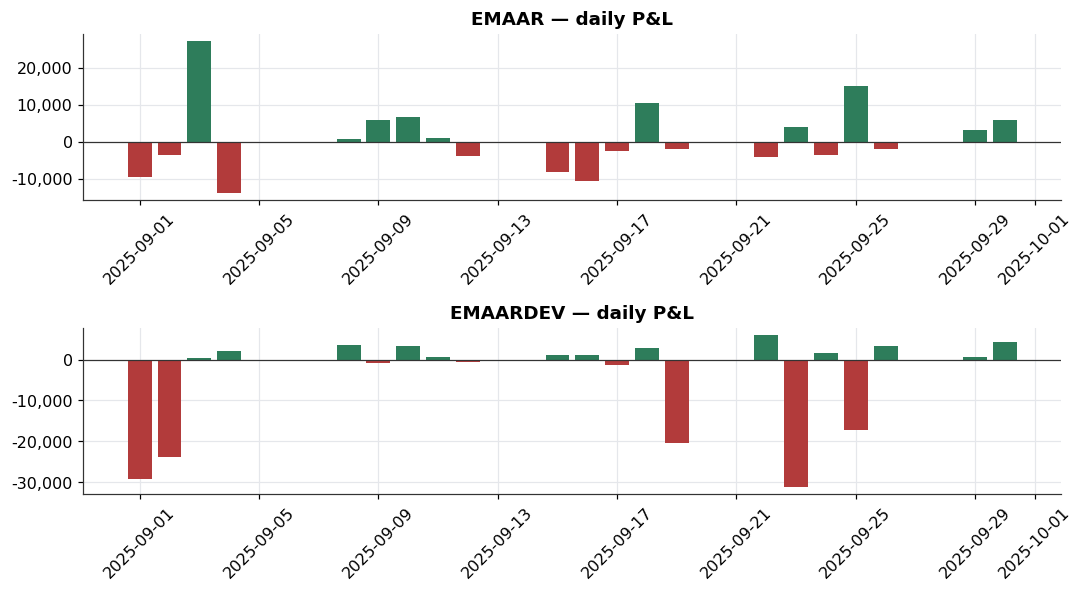

In [5]:
fig, axes = plt.subplots(len(stocks), 1, figsize=(10, 5.5), sharex=False)
for ax, stock in zip(axes, stocks):
    s = short(stock)
    g = daily[daily.stock == stock].sort_values("date")
    colors = np.where(g.final_pnl_aed >= 0, GREEN, RED)
    ax.bar(g.date, g.final_pnl_aed, color=colors, width=0.8)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_title(f"{s} — daily P&L")
    money(ax)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Cumulative P&L

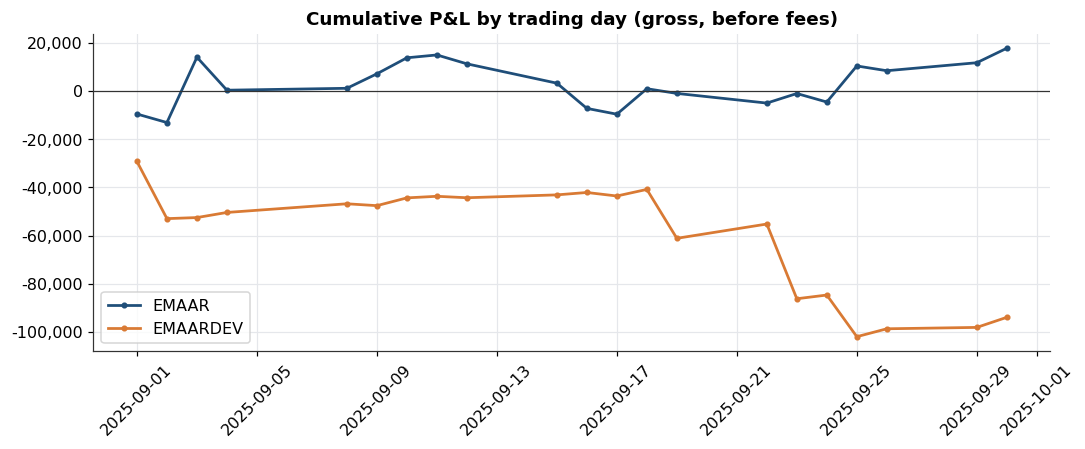

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.2))
for stock in stocks:
    g = daily[daily.stock == stock].sort_values("date")
    ax.plot(g.date, g.final_pnl_aed.cumsum(), marker="o", markersize=3,
            label=short(stock), color=COLOR[short(stock)], linewidth=1.8)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_title("Cumulative P&L by trading day (gross, before fees)")
ax.legend()
money(ax)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## P&L distribution & key statistics

,mean,median,std,skew,min,max,best_day,worst_day
stock,,,,,,,,
EMAAR,848.16,"-1,955.70","9,288.29",1.08,"-13,706.20","27,146.70",03-Sep,04-Sep
EMAARDEV,"-4,476.36",663.95,"11,795.13",-1.42,"-31,046.10","5,934.60",22-Sep,23-Sep


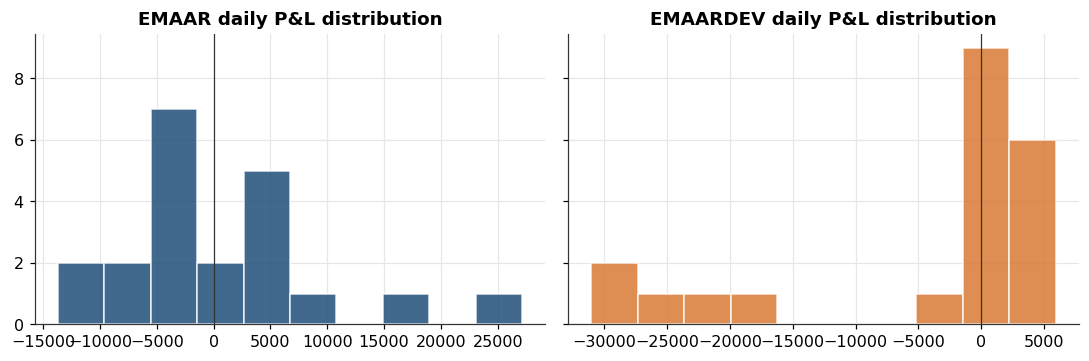

In [7]:
stats_rows = []
for stock in stocks:
    g = daily[daily.stock == stock]["final_pnl_aed"]
    stats_rows.append({
        "stock": short(stock), "mean": g.mean(), "median": g.median(), "std": g.std(),
        "skew": g.skew(), "min": g.min(), "max": g.max(),
        "best_day": daily.loc[(daily.stock == stock) & (daily.final_pnl_aed == g.max()), "date"].dt.strftime("%d-%b").iloc[0],
        "worst_day": daily.loc[(daily.stock == stock) & (daily.final_pnl_aed == g.min()), "date"].dt.strftime("%d-%b").iloc[0],
    })
stats_df = pd.DataFrame(stats_rows).set_index("stock")
display(stats_df.style.format("{:,.2f}", subset=["mean", "median", "std", "skew", "min", "max"])
        .set_caption("Daily P&L distribution statistics (AED)"))

fig, axes = plt.subplots(1, len(stocks), figsize=(10, 3.4), sharey=True)
for ax, stock in zip(axes, stocks):
    s = short(stock)
    g = daily[daily.stock == stock]["final_pnl_aed"]
    ax.hist(g, bins=10, color=COLOR[s], alpha=0.85, edgecolor="white")
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set_title(f"{s} daily P&L distribution")
plt.tight_layout()
plt.show()

In [8]:
best_row = daily.loc[daily.final_pnl_aed.idxmax()]
best_stock_short = short(best_row.stock)
rest_total = daily.loc[daily.stock == best_row.stock, "final_pnl_aed"].sum() - best_row.final_pnl_aed
print(f"{best_stock_short}'s single best day ({best_row.date:%d %b}, {best_row.final_pnl_aed:+,.2f} AED) "
      f"is not representative -- the other {n_days - 1} days for that name net to "
      f"{rest_total:+,.2f} AED on their own.")

EMAAR's single best day (03 Sep, +27,146.70 AED) is not representative -- the other 20 days for that name net to -9,335.30 AED on their own.


## Drawdown, volume, fills, win/loss days

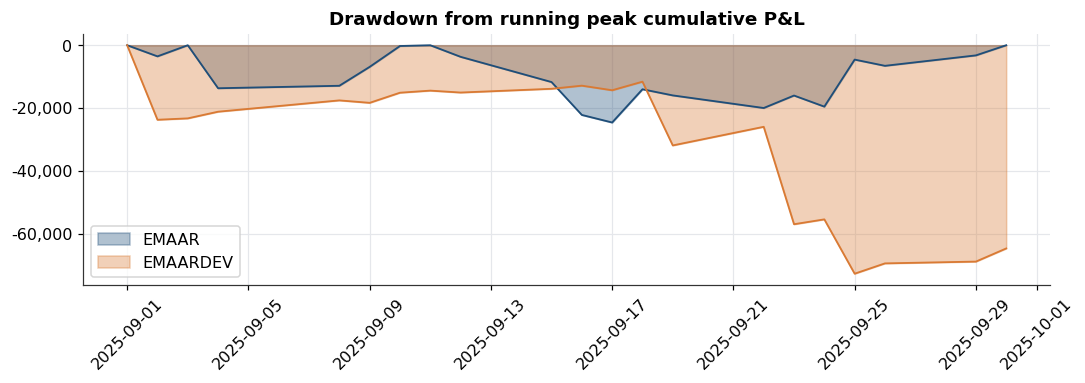

,total_volume_shares,total_number_of_fills,max_drawdown_aed,profitable_days,losing_days,flat_days
stock,,,,,,
EMAAR,"16,625,257",19179,"-24,620.45",10,11,0
EMAARDEV,"8,393,511",9523,"-72,804.90",13,8,0


In [9]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for stock in stocks:
    g = daily[daily.stock == stock].sort_values("date")
    cum = g.final_pnl_aed.cumsum()
    dd = cum - cum.cummax()
    ax.fill_between(g.date, dd, 0, color=COLOR[short(stock)], alpha=0.35, label=short(stock))
    ax.plot(g.date, dd, color=COLOR[short(stock)], linewidth=1.2)
ax.set_title("Drawdown from running peak cumulative P&L")
ax.legend()
money(ax)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

winloss = daily.groupby("stock").apply(
    lambda g: pd.Series({
        "profitable_days": int((g.final_pnl_aed > 0).sum()),
        "losing_days": int((g.final_pnl_aed < 0).sum()),
        "flat_days": int((g.final_pnl_aed == 0).sum()),
    }), include_groups=False
)
winloss.index = [short(s) for s in winloss.index]
vol_fill_tbl = summary.set_index(summary["stock"].map(short))[
    ["total_volume_shares", "total_number_of_fills", "max_drawdown_aed"]
].join(winloss)
display(vol_fill_tbl.style.format({"total_volume_shares": "{:,.0f}", "max_drawdown_aed": "{:,.2f}"})
        .set_caption("Volume, fills and win/loss days (from summary.csv + daily_pnl.csv)"))

## Inventory path — the most extreme single-day build-up

Rather than assume which stock-day is most extreme, this pulls it directly
from `daily_pnl.csv` (largest `max_long_inventory`) and plots the intraday
path from `fills.csv`.

(Largest inventory build across both names is actually EMAAR on 24 Sep at 110,701 shares -- shown here is EMAARDEV's own largest, the one flagged for follow-up.)


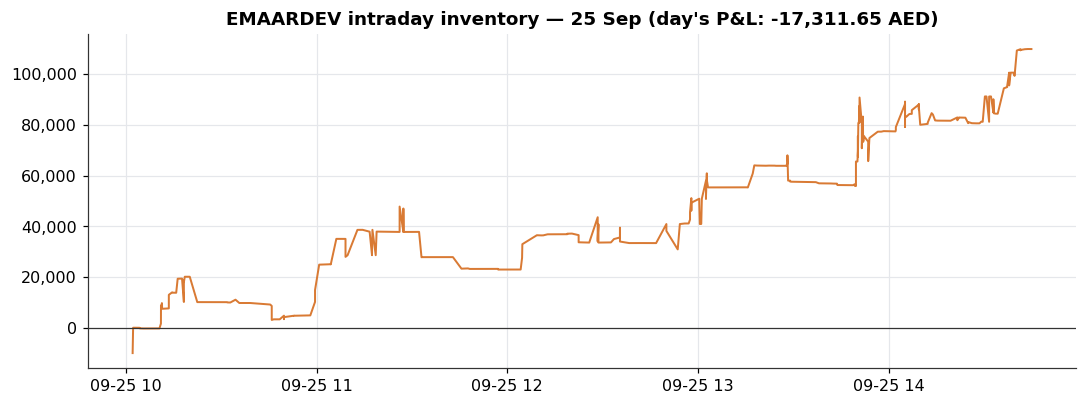

Long inventory on this day peaks at 109,890 shares with nothing in the baseline strategy pulling against it. Day's P&L: -17,311.65 AED. See the skew comparison below for what changes on this exact day under an inventory-aware quote.


In [10]:
emaardev_name = [s for s in stocks if "EMAARDEV" in s][0]
emaardev_daily = daily[daily.stock == emaardev_name]
worst_inv_row = emaardev_daily.loc[emaardev_daily["max_long_inventory"].idxmax()]
target_stock, target_date = worst_inv_row["stock"], worst_inv_row["date"]

# For context: is this also the largest inventory build across *both* names?
global_worst = daily.loc[daily["max_long_inventory"].idxmax()]
if global_worst["stock"] != target_stock or global_worst["date"] != target_date:
    print(f"(Largest inventory build across both names is actually {short(global_worst.stock)} "
          f"on {global_worst.date:%d %b} at {global_worst.max_long_inventory:,.0f} shares -- "
          f"shown here is {short(target_stock)}'s own largest, the one flagged for follow-up.)")

day_fills = fills[(fills.stock == target_stock) & (fills.timestamp.dt.date == target_date.date())].sort_values("timestamp")
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(day_fills.timestamp, day_fills.inventory_after, color=COLOR[short(target_stock)], linewidth=1.3)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_title(f"{short(target_stock)} intraday inventory — {target_date:%d %b} "
             f"(day's P&L: {worst_inv_row.final_pnl_aed:+,.2f} AED)")
money(ax)
plt.tight_layout()
plt.show()

print(f"Long inventory on this day peaks at {worst_inv_row.max_long_inventory:,.0f} shares with "
      f"nothing in the baseline strategy pulling against it. Day's P&L: "
      f"{worst_inv_row.final_pnl_aed:+,.2f} AED. See the skew comparison below for what changes "
      f"on this exact day under an inventory-aware quote.")

## Baseline vs. inventory-skew

,Baseline P&L,Skewed P&L,Baseline max DD,Skewed max DD,Baseline win rate,Skewed win rate
stock,,,,,,
EMAAR,"17,811.40","55,545.75","-24,620.45","-3,281.05",48%,76%
EMAARDEV,"-94,003.55","-37,783.25","-72,804.90","-28,428.95",62%,43%


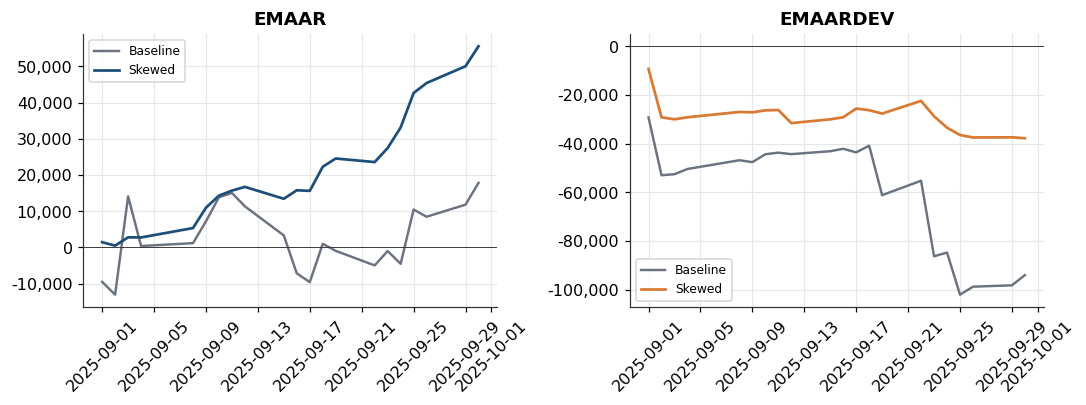

Same 25 Sep day: max long inventory falls from 109,890 to 35,153 shares, P&L moves from -17,311.65 to -2,994.05 AED.


In [11]:
cmp_rows = []
for stock in stocks:
    b = summary[summary.stock == stock].iloc[0]
    sk = summary_skew[summary_skew.stock == stock].iloc[0]
    cmp_rows.append({
        "stock": short(stock),
        "Baseline P&L": b.total_pnl_aed, "Skewed P&L": sk.total_pnl_aed,
        "Baseline max DD": b.max_drawdown_aed, "Skewed max DD": sk.max_drawdown_aed,
        "Baseline win rate": b.profitable_days / b.number_of_trading_days,
        "Skewed win rate": sk.profitable_days / sk.number_of_trading_days,
    })
cmp_df = pd.DataFrame(cmp_rows).set_index("stock")
display(cmp_df.style.format({c: "{:,.2f}" for c in cmp_df.columns if "rate" not in c}
                             | {c: "{:.0%}" for c in cmp_df.columns if "rate" in c})
        .set_caption("Baseline vs. one unoptimized inventory-skew pass (skew_variant.py)"))

fig, axes = plt.subplots(1, len(stocks), figsize=(10, 3.8), sharex=False)
for ax, stock in zip(axes, stocks):
    gb = daily[daily.stock == stock].sort_values("date")
    gs = daily_skew[daily_skew.stock == stock].sort_values("date")
    ax.plot(gb.date, gb.final_pnl_aed.cumsum(), label="Baseline", color=GRAY, linewidth=1.6)
    ax.plot(gs.date, gs.final_pnl_aed.cumsum(), label="Skewed", color=COLOR[short(stock)], linewidth=1.8)
    ax.axhline(0, color="#333333", linewidth=0.6)
    ax.set_title(short(stock))
    ax.legend(fontsize=8)
    money(ax)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

target_skew_row = daily_skew[(daily_skew.stock == target_stock) & (daily_skew.date == target_date)].iloc[0]
print(f"Same {target_date:%d %b} day: max long inventory falls from "
      f"{worst_inv_row.max_long_inventory:,.0f} to {target_skew_row.max_long_inventory:,.0f} shares, "
      f"P&L moves from {worst_inv_row.final_pnl_aed:+,.2f} to {target_skew_row.final_pnl_aed:+,.2f} AED.")

## Fees: gross P&L / variable / flat / net

Variable fee = 15.5 bps × gross traded value. Flat fee = AED 10.50 × number
of chargeable orders (one resting-quote instance with ≥1 fill; see README
§8 and `fee_adjusted_summary.csv` for the exact definition used).

,gross_traded,reported_pnl,n_orders,variable_fee,flat_fee,total_fee,net_pnl
stock,,,,,,,
EMAAR UH Equity,"231,153,735.85","17,811.40","5,790.00","358,288.29","60,795.00","419,083.29","-401,271.89"
EMAARDEV UH Equity,"118,951,907.30","-94,003.55","3,191.00","184,375.46","33,505.50","217,880.96","-311,884.51"


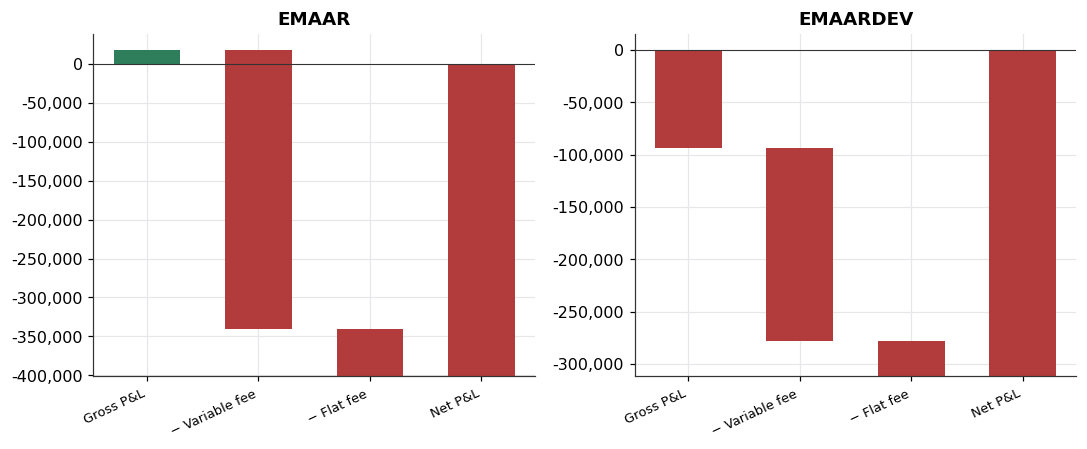

In [12]:
display(fees.set_index("stock").style.format("{:,.2f}").set_caption("fee_adjusted_summary.csv, as generated"))

fig, axes = plt.subplots(1, len(stocks), figsize=(10, 4.2))
for ax, stock in zip(axes, stocks):
    row = fees[fees.stock == stock].iloc[0]
    gross, var_fee, flat_fee, net = row.reported_pnl, row.variable_fee, row.flat_fee, row.net_pnl
    after_var = gross - var_fee
    # (start, end, is_total) for each step -- bar spans [min(start,end), max(start,end)]
    steps = [(0, gross, True), (gross, after_var, False), (after_var, net, False), (0, net, True)]
    labels = ["Gross P&L", "− Variable fee", "− Flat fee", "Net P&L"]
    for i, (start, end, is_total) in enumerate(steps):
        color = (GREEN if end >= 0 else RED) if is_total else RED
        ax.bar(i, abs(end - start), bottom=min(start, end), color=color, width=0.6)
    ax.axhline(0, color="#333333", linewidth=0.7)
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8.5)
    ax.set_title(short(stock))
    money(ax)
plt.tight_layout()
plt.show()

## 14:45 vs. 15:00 sensitivity

The primary run stops fills at 14:45:00. `results_1500_sensitivity/` is a
real re-run with the literal spec cutoff (15:00:00) instead — same engine,
same locked-market fix, nothing else changed.

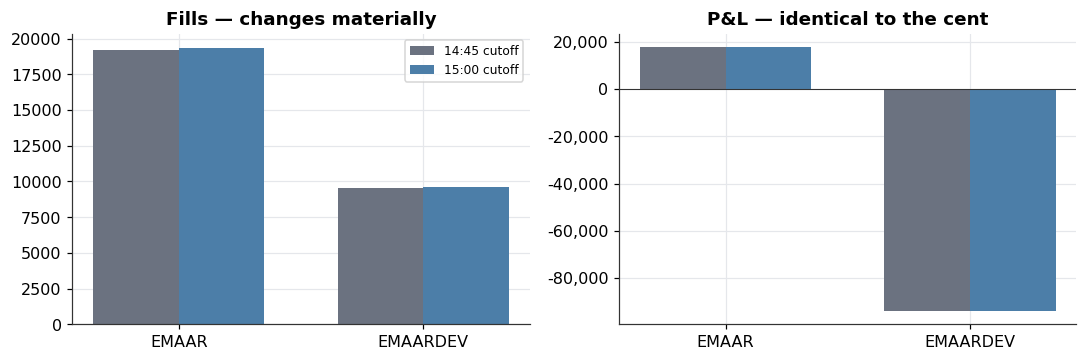

Extending the cutoff to 15:00 adds 303 more matched fills across both names, changes total P&L by 0.0000 AED -- i.e. nothing. Every post-14:45 trade prints at that day's own liquidation price, so buying or selling into that window is a wash by construction (see README §5).


In [13]:
sens_cmp = summary.set_index(summary["stock"].map(short))[["total_pnl_aed", "total_gross_traded_value_aed", "total_number_of_fills"]]
sens_cmp.columns = pd.MultiIndex.from_product([["14:45 cutoff"], sens_cmp.columns])
sens_1500 = summary_1500.set_index(summary_1500["stock"].map(short))[["total_pnl_aed", "total_gross_traded_value_aed", "total_number_of_fills"]]
sens_1500.columns = pd.MultiIndex.from_product([["15:00 cutoff"], sens_1500.columns])
sens_table = sens_cmp.join(sens_1500)
sens_table[("Δ", "total_pnl_aed")] = sens_table[("15:00 cutoff", "total_pnl_aed")] - sens_table[("14:45 cutoff", "total_pnl_aed")]
display(sens_table.style.format("{:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
x = np.arange(len(stocks))
w = 0.35
fills_1445 = [summary.loc[summary.stock == s, "total_number_of_fills"].iloc[0] for s in stocks]
fills_1500 = [summary_1500.loc[summary_1500.stock == s, "total_number_of_fills"].iloc[0] for s in stocks]
pnl_1445 = [summary.loc[summary.stock == s, "total_pnl_aed"].iloc[0] for s in stocks]
pnl_1500 = [summary_1500.loc[summary_1500.stock == s, "total_pnl_aed"].iloc[0] for s in stocks]

axes[0].bar(x - w/2, fills_1445, w, label="14:45 cutoff", color=GRAY)
axes[0].bar(x + w/2, fills_1500, w, label="15:00 cutoff", color="#4c7ea8")
axes[0].set_xticks(x); axes[0].set_xticklabels([short(s) for s in stocks])
axes[0].set_title("Fills — changes materially")
axes[0].legend(fontsize=8)

axes[1].bar(x - w/2, pnl_1445, w, label="14:45 cutoff", color=GRAY)
axes[1].bar(x + w/2, pnl_1500, w, label="15:00 cutoff", color="#4c7ea8")
axes[1].set_xticks(x); axes[1].set_xticklabels([short(s) for s in stocks])
axes[1].axhline(0, color="#333333", linewidth=0.7)
axes[1].set_title("P&L — identical to the cent")
money(axes[1])
plt.tight_layout()
plt.show()

max_delta = sens_table[("Δ", "total_pnl_aed")].abs().max()
extra_fills = sum(f1500 - f1445 for f1445, f1500 in zip(fills_1445, fills_1500))
print(f"Extending the cutoff to 15:00 adds {extra_fills:,} more matched fills across both names, "
      f"changes total P&L by {max_delta:,.4f} AED -- i.e. nothing. Every post-14:45 trade prints "
      f"at that day's own liquidation price, so buying or selling into that window is a wash by "
      f"construction (see README §5).")

## Half-sample robustness check

In [14]:
all_dates = sorted(daily["date"].unique())
midpoint = len(all_dates) // 2
first_half_dates = all_dates[:midpoint]
second_half_dates = all_dates[midpoint:]

print(f"{len(all_dates)} trading days, split at the chronological midpoint: "
      f"first half = {len(first_half_dates)} days "
      f"({pd.Timestamp(first_half_dates[0]):%d %b}-{pd.Timestamp(first_half_dates[-1]):%d %b}); "
      f"second half = {len(second_half_dates)} days "
      f"({pd.Timestamp(second_half_dates[0]):%d %b}-{pd.Timestamp(second_half_dates[-1]):%d %b}).")


def half_stats(g: pd.DataFrame) -> pd.Series:
    g = g.sort_values("date")
    cum = g["final_pnl_aed"].cumsum()
    dd = float((cum - cum.cummax()).min()) if len(cum) else 0.0
    return pd.Series({
        "Total P&L": g["final_pnl_aed"].sum(),
        "Avg daily P&L": g["final_pnl_aed"].mean(),
        "Max drawdown": dd,
        "Winning days": int((g["final_pnl_aed"] > 0).sum()),
        "Losing days": int((g["final_pnl_aed"] < 0).sum()),
        "Fills": int((g["number_of_buy_fills"] + g["number_of_sell_fills"]).sum()),
        "Gross traded value": g["gross_traded_value"].sum(),
    })


half_rows = []
for stock in stocks:
    g = daily[daily.stock == stock]
    h1, h2 = half_stats(g[g.date.isin(first_half_dates)]), half_stats(g[g.date.isin(second_half_dates)])
    h1.name, h2.name = (short(stock), f"First half ({len(first_half_dates)}d)"), (short(stock), f"Second half ({len(second_half_dates)}d)")
    half_rows += [h1, h2]

half_df = pd.DataFrame(half_rows)
half_df.index = pd.MultiIndex.from_tuples(half_df.index, names=["Stock", "Half"])
display(half_df.style.format({
    "Total P&L": "{:,.2f}", "Avg daily P&L": "{:,.2f}", "Max drawdown": "{:,.2f}",
    "Winning days": "{:.0f}", "Losing days": "{:.0f}", "Fills": "{:,.0f}", "Gross traded value": "{:,.0f}",
}).set_caption("Half-sample robustness check — chronological split (NOT an out-of-sample test)"))

21 trading days, split at the chronological midpoint: first half = 10 days (01 Sep-15 Sep); second half = 11 days (16 Sep-30 Sep).


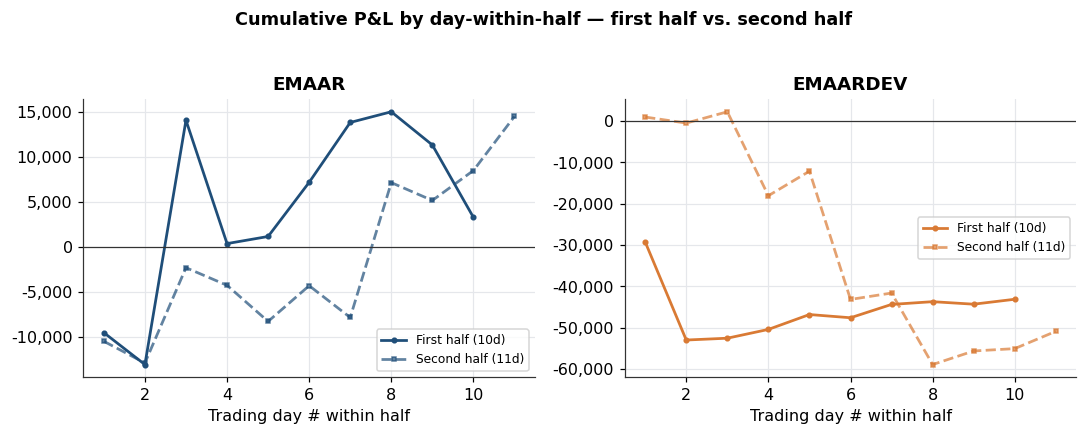

In [15]:
fig, axes = plt.subplots(1, len(stocks), figsize=(10, 3.8))
for ax, stock in zip(axes, stocks):
    g = daily[daily.stock == stock].sort_values("date")
    g1 = g[g.date.isin(first_half_dates)].reset_index(drop=True)
    g2 = g[g.date.isin(second_half_dates)].reset_index(drop=True)
    ax.plot(range(1, len(g1) + 1), g1["final_pnl_aed"].cumsum(), marker="o", markersize=3,
            label=f"First half ({len(g1)}d)", color=COLOR[short(stock)], linewidth=1.8)
    ax.plot(range(1, len(g2) + 1), g2["final_pnl_aed"].cumsum(), marker="s", markersize=3,
            label=f"Second half ({len(g2)}d)", color=COLOR[short(stock)], linewidth=1.8,
            linestyle="--", alpha=0.7)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_title(short(stock))
    ax.set_xlabel("Trading day # within half")
    ax.legend(fontsize=8)
    money(ax)
fig.suptitle("Cumulative P&L by day-within-half — first half vs. second half", y=1.03,
             fontsize=11.5, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
same_sign = {
    short(s): (half_df.loc[(short(s), f"First half ({len(first_half_dates)}d)"), "Total P&L"] >= 0)
               == (half_df.loc[(short(s), f"Second half ({len(second_half_dates)}d)"), "Total P&L"] >= 0)
    for s in stocks
}
bits = [
    f"{short(s)}: {half_df.loc[(short(s), f'First half ({len(first_half_dates)}d)'), 'Total P&L']:+,.2f} AED "
    f"(first half) vs {half_df.loc[(short(s), f'Second half ({len(second_half_dates)}d)'), 'Total P&L']:+,.2f} AED "
    f"(second half), {'same sign' if same_sign[short(s)] else 'sign flips'} across the split"
    for s in stocks
]
print("Chronological split result: " + "; ".join(bits) + ".")

Chronological split result: EMAAR: +3,294.80 AED (first half) vs +14,516.60 AED (second half), same sign across the split; EMAARDEV: -43,120.15 AED (first half) vs -50,883.40 AED (second half), same sign across the split.


## Conclusions

In [19]:
# - Gross, the two names net -76,192.15 AED across 21 days -- after DFM's fee schedule that becomes -713,156.40 AED. Naive symmetric join-the-touch market making loses money here.
# - EMAAR's gross result is one large day, not a steady edge: exclude 03 Sep and the remaining days net to -9,335.30 AED.
# - The 14:45 vs. 15:00 session-end choice has zero effect on P&L -- confirmed directly, not assumed.
# - A single, unoptimized inventory-skew pass moves gross P&L from -76,192.15 AED to +17,762.50 AED and cuts both names' max drawdown substantially - the clearest lever available on top of this engine.
# - Half-sample robustness check (not out-of-sample): both names keep the same sign across the chronological split.